# 🏥 Prescription Line Segmentation Pipeline
### Full workflow from raw prescription images → segmented medicine lines → ready for HTR model

---

## 📁 Expected Folder Structure

```
project_root/
│
├── data/
│   ├── raw_images/                  ← PUT YOUR RAW PRESCRIPTION PHOTOS HERE
│   ├── preprocessed_images/         ← Step 1 output (cleaned images)
│   ├── roi_images/                  ← Step 2 output (medicine section cropped)
│   ├── segmentation_masks/          ← Step 3 output (your hand-drawn annotations)
│   ├── isolated_medicines/          ← Step 6 output (DeepLab isolated regions)
│   ├── segmented_lines/             ← Step 7 output (FINAL: 128x32 line crops)
│   └── skipped_images.txt           ← Auto-created by annotator
│
├── models/
│   ├── deeplab_medicine_detector.pth  ← Step 4 output (YOUR TRAINED MODEL)
│   ├── craft_mlt_25k.pth              ← Download separately (CRAFT weights)
│   └── rx_template.jpg                ← Optional: crop of 'Rx' symbol for template matching
│
├── libs/
│   └── CRAFT-pytorch/               ← git clone https://github.com/clovaai/CRAFT-pytorch.git
│
├── htr_input/                       ← HANDOFF FOLDER FOR HTR MODEL
│   ├── line_crops/                  ← Copy of segmented_lines (128x32 images)
│   └── pipeline_config.json         ← Pipeline metadata saved here
│
└── scripts/                         ← Your .py files live here
    ├── preprocessing.py
    ├── preprocessWithDeskew.py
    ├── extract_roi.py
    ├── annotator.py
    ├── train_deeplab.py
    ├── debug_dataset.py
    ├── inference_deeplab.py
    └── craft_segmentation.py
```

---

## ⚙️ Pipeline Overview

| Step | File | Input | Output |
|------|------|-------|--------|
| 1 | preprocessing (with deskew) | raw_images/ | preprocessed_images/ |
| 2 | extract_roi | preprocessed_images/ | roi_images/ |
| 3 | annotator *(manual)* | roi_images/ | segmentation_masks/ |
| 4 | train_deeplab | roi_images/ + segmentation_masks/ | models/deeplab_medicine_detector.pth |
| 5 | debug_dataset | (training logs) | loss curve plot |
| 6 | inference_deeplab | preprocessed_images/ | isolated_medicines/ |
| 7 | craft_segmentation | isolated_medicines/ | segmented_lines/ |
| 8 | **Save for HTR** | segmented_lines/ + models/ | htr_input/ |


---
## 🔧 CELL 0 — Setup: Create All Folders & Install Dependencies

In [1]:
import os
from pathlib import Path

# ─────────────────────────────────────────────────────────────
# SET YOUR PROJECT ROOT HERE
# Change this to wherever your project folder lives
# ─────────────────────────────────────────────────────────────
PROJECT_ROOT = os.path.abspath(".")  # Default: current working directory
# PROJECT_ROOT = "/path/to/your/project"  # Uncomment and set manually if needed

print(f"Project root: {PROJECT_ROOT}")

# ── All folder paths ──────────────────────────────────────────
PATHS = {
    "raw_images":           os.path.join(PROJECT_ROOT, "data", "raw_images"),
    "preprocessed_images":  os.path.join(PROJECT_ROOT, "data", "preprocessed_images"),
    "roi_images":           os.path.join(PROJECT_ROOT, "data", "roi_images"),
    "segmentation_masks":   os.path.join(PROJECT_ROOT, "data", "segmentation_masks"),
    "isolated_medicines":   os.path.join(PROJECT_ROOT, "data", "isolated_medicines"),
    "segmented_lines":      os.path.join(PROJECT_ROOT, "data", "segmented_lines"),
    "models":               os.path.join(PROJECT_ROOT, "models"),
    "htr_input":            os.path.join(PROJECT_ROOT, "htr_input"),
    "htr_line_crops":       os.path.join(PROJECT_ROOT, "htr_input", "line_crops"),
    "libs":                 os.path.join(PROJECT_ROOT, "libs"),
    "logs":                 os.path.join(PROJECT_ROOT, "data", "logs"),
}

# Create all folders
for name, path in PATHS.items():
    Path(path).mkdir(parents=True, exist_ok=True)
    print(f"  ✅ {name:25s} → {path}")

print("\nAll folders are ready!")

Project root: /Users/avishkashenan/Desktop/Line Segmentation New
  ✅ raw_images                → /Users/avishkashenan/Desktop/Line Segmentation New/data/raw_images
  ✅ preprocessed_images       → /Users/avishkashenan/Desktop/Line Segmentation New/data/preprocessed_images
  ✅ roi_images                → /Users/avishkashenan/Desktop/Line Segmentation New/data/roi_images
  ✅ segmentation_masks        → /Users/avishkashenan/Desktop/Line Segmentation New/data/segmentation_masks
  ✅ isolated_medicines        → /Users/avishkashenan/Desktop/Line Segmentation New/data/isolated_medicines
  ✅ segmented_lines           → /Users/avishkashenan/Desktop/Line Segmentation New/data/segmented_lines
  ✅ models                    → /Users/avishkashenan/Desktop/Line Segmentation New/models
  ✅ htr_input                 → /Users/avishkashenan/Desktop/Line Segmentation New/htr_input
  ✅ htr_line_crops            → /Users/avishkashenan/Desktop/Line Segmentation New/htr_input/line_crops
  ✅ libs                

In [2]:
# Install required packages (run once)
# Comment out after first run to save time

import subprocess
packages = ["opencv-python", "torch", "torchvision", "tqdm", "matplotlib", "numpy"]
for pkg in packages:
    subprocess.run(["pip", "install", pkg, "-q"])
    print(f"  ✅ {pkg}")

print("\nAll packages ready!")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


  ✅ opencv-python



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


  ✅ torch



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


...


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


  ✅ tqdm



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


  ✅ matplotlib
  ✅ numpy

All packages ready!



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


---
## 📌 STEP 1 — Preprocessing with Deskew
**What it does:** Converts raw prescription images to clean black-and-white. Detects and corrects any tilt/skew in the photo. Applies adaptive thresholding to handle uneven lighting.

**Input:**  `data/raw_images/`  
**Output:** `data/preprocessed_images/`

In [3]:
import cv2
import numpy as np
import csv
import os
from pathlib import Path


def deskew_image(gray):
    """Detect skew angle using Hough Transform and rotate image."""
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLines(edges, 1, np.pi / 180, 200)
    angle = 0.0
    if lines is not None:
        angles = []
        for rho, theta in lines[:, 0]:
            angle_deg = (theta * 180 / np.pi) - 90
            angles.append(angle_deg)
        angle = np.median(angles)
        (h, w) = gray.shape
        center = (w // 2, h // 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(gray, M, (w, h),
                                  flags=cv2.INTER_CUBIC,
                                  borderMode=cv2.BORDER_REPLICATE)
        return rotated, angle
    return gray, angle


def preprocess_images(input_dir, output_dir, log_path):
    """Full preprocessing pipeline with deskew + logging."""
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    Path(os.path.dirname(log_path)).mkdir(parents=True, exist_ok=True)

    with open(log_path, mode='w', newline='') as log_file:
        writer = csv.writer(log_file)
        writer.writerow(["filename", "status", "skew_angle"])

        image_paths = []
        if os.path.exists(input_dir):
            for filename in os.listdir(input_dir):
                full_path = os.path.join(input_dir, filename)
                if os.path.isfile(full_path) and not filename.startswith('.'):
                    image_paths.append(full_path)

        if not image_paths:
            print(f"⚠️  No images found in '{input_dir}'")
            return

        print(f"Found {len(image_paths)} files. Starting preprocessing...")
        kernel = np.ones((3, 3), np.uint8)

        for img_path in image_paths:
            filename = os.path.basename(img_path)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    print(f"  Skipping unreadable file: {filename}")
                    writer.writerow([filename, "failed_read", "N/A"])
                    continue

                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                gray, angle = deskew_image(gray)

                thresh = cv2.adaptiveThreshold(
                    gray, 255,
                    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                    cv2.THRESH_BINARY_INV, 15, 5
                )
                dilated = cv2.dilate(thresh, kernel, iterations=1)
                final_img = cv2.bitwise_not(dilated)

                name_without_ext = os.path.splitext(filename)[0]
                out_path = os.path.join(output_dir, f"{name_without_ext}.jpg")
                cv2.imwrite(out_path, final_img)

                print(f"  ✅ Processed: {filename} | Angle: {angle:.2f}°")
                writer.writerow([filename, "success", round(angle, 2)])

            except Exception as e:
                print(f"  ❌ Error processing {filename}: {str(e)}")
                writer.writerow([filename, "error", "N/A"])

    print(f"\n✅ Step 1 Complete!")
    print(f"   Images saved to : {output_dir}")
    print(f"   Log saved to    : {log_path}")


# ── RUN STEP 1 ───────────────────────────────────────────────
preprocess_images(
    input_dir  = PATHS["raw_images"],
    output_dir = PATHS["preprocessed_images"],
    log_path   = os.path.join(PATHS["logs"], "preprocessing_log.csv")
)

Found 600 files. Starting preprocessing...
  ✅ Processed: 177918_0.Jpg | Angle: -76.00°
  ✅ Processed: 176918_0.Jpg | Angle: 12.00°
  ✅ Processed: 177532_0.Jpg | Angle: 1.00°
  ✅ Processed: 177864_1.Jpg | Angle: -87.00°
  ✅ Processed: 177347_0.Jpg | Angle: -83.00°
  ✅ Processed: 176840_0.Jpg | Angle: 5.00°
  ✅ Processed: 177387_0.Jpg | Angle: -1.00°
  ✅ Processed: 177756_0.Jpg | Angle: -1.00°
  ✅ Processed: 177412_0.Jpg | Angle: 15.50°
  ✅ Processed: 176880_0.Jpg | Angle: -88.00°
  ✅ Processed: 177142_1.Jpg | Angle: -57.00°
  ✅ Processed: 177901_1.Jpg | Angle: -2.00°
  ✅ Processed: 177944_1.Jpg | Angle: 7.00°
  ✅ Processed: 177882_2.Jpg | Angle: -13.00°
  ✅ Processed: 177166_0.Jpg | Angle: 9.00°
  ✅ Processed: 177123_0.Jpg | Angle: 6.00°
  ✅ Processed: 176925_0.Jpg | Angle: 9.00°
  ✅ Processed: 177859_0.Jpg | Angle: -86.00°
  ✅ Processed: 177901_0.Jpg | Angle: 0.00°
  ✅ Processed: 177142_0.Jpg | Angle: -45.00°
  ✅ Processed: 177944_0.Jpg | Angle: 7.00°
  ✅ Processed: 177471_2.Jpg | Ang

---
## 📌 STEP 2 — Extract ROI (Region of Interest)
**What it does:** Removes the doctor/hospital header (top 25%) and footer (bottom 20%) from each prescription. Keeps only the medicine writing section.

**Input:**  `data/preprocessed_images/`  
**Output:** `data/roi_images/`

In [4]:
import cv2
import os
from pathlib import Path


def crop_by_percentage(image, top_pct=0.25, bottom_pct=0.20):
    """Slice off header and footer by fixed percentages."""
    h, w = image.shape[:2]
    start_y = int(h * top_pct)
    end_y   = int(h * (1.0 - bottom_pct))
    return image[start_y:end_y, 0:w]


def extract_roi_from_folder(input_dir, output_dir, top_pct=0.25, bottom_pct=0.20):
    """Reads images, applies crop strategy, and saves ROI crops."""
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    image_paths = []
    if os.path.exists(input_dir):
        for filename in sorted(os.listdir(input_dir)):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                image_paths.append(os.path.join(input_dir, filename))

    if not image_paths:
        print(f"⚠️  No images found in {input_dir}")
        return

    print(f"Starting ROI Extraction on {len(image_paths)} images...")
    crops_saved = 0

    for img_path in image_paths:
        filename = os.path.basename(img_path)
        image = cv2.imread(img_path)
        if image is None:
            print(f"  Skipping {filename} (could not read)")
            continue

        roi_image = crop_by_percentage(image, top_pct, bottom_pct)
        out_path  = os.path.join(output_dir, filename)
        cv2.imwrite(out_path, roi_image)
        crops_saved += 1

    print(f"\n✅ Step 2 Complete!")
    print(f"   {crops_saved} ROI images saved to: {output_dir}")
    print(f"\n   💡 Tip: If the crop is cutting too much/little,")
    print(f"      adjust top_pct and bottom_pct values above.")


# ── RUN STEP 2 ───────────────────────────────────────────────
# top_pct  = how much to cut from the TOP (doctor header)
# bottom_pct = how much to cut from the BOTTOM (footer)
extract_roi_from_folder(
    input_dir  = PATHS["preprocessed_images"],
    output_dir = PATHS["roi_images"],
    top_pct    = 0.25,
    bottom_pct = 0.20
)

Starting ROI Extraction on 600 images...

✅ Step 2 Complete!
   600 ROI images saved to: /Users/avishkashenan/Desktop/Line Segmentation New/data/roi_images

   💡 Tip: If the crop is cutting too much/little,
      adjust top_pct and bottom_pct values above.


---
## 📌 STEP 3 — Manual Annotation (Create Training Masks)
**What it does:** Opens each ROI image in a window. You click 4 corners around the medicine region to draw a mask polygon. Press `S` to save, `N` to skip, `C` to clear, `Q` to quit.

> ⚠️ **This is an interactive step.** It opens a separate OpenCV window. Run it as a standalone script from your terminal, not inside Jupyter:
> ```bash
> python scripts/annotator.py
> ```

**Input:**  `data/roi_images/`  
**Output:** `data/segmentation_masks/` (binary white polygon on black background)

In [5]:
# ── STEP 3: RUN ANNOTATOR ────────────────────────────────────
# This cell launches the annotator as a subprocess.
# A separate window will open — annotate your images there.

import subprocess
import os

annotator_script = os.path.join(PROJECT_ROOT, "scripts", "annotator.py")

if os.path.exists(annotator_script):
    print("Launching annotator window...")
    print("Controls: [S] Save  |  [N] Skip  |  [C] Clear  |  [Q] Quit")
    subprocess.run(["python", annotator_script])
    print("\n✅ Annotation session ended.")
else:
    # Inline fallback if scripts/ folder isn't set up
    print("⚠️  annotator.py not found at:", annotator_script)
    print("   Please run it directly from terminal:")
    print(f"   python {annotator_script}")

# Check how many masks were created
mask_count = len([f for f in os.listdir(PATHS["segmentation_masks"])
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
print(f"\n   {mask_count} masks currently in: {PATHS['segmentation_masks']}")

Launching annotator window...
Controls: [S] Save  |  [N] Skip  |  [C] Clear  |  [Q] Quit

Dataset Complete! You have finished all images.

✅ Annotation session ended.

   407 masks currently in: /Users/avishkashenan/Desktop/Line Segmentation New/data/segmentation_masks


---
## 📌 STEP 4 — Train DeepLabV3+ Segmentation Model
**What it does:** Trains a DeepLabV3+ neural network using your annotated image+mask pairs. Learns to distinguish medicine writing regions from background. Runs for 15 epochs.

**Input:**  `data/roi_images/` + `data/segmentation_masks/`  
**Output:** `models/deeplab_medicine_detector.pth`

In [6]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from tqdm import tqdm
import numpy as np
from pathlib import Path


# ── Dataset ──────────────────────────────────────────────────
class PrescriptionDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=(512, 512)):
        self.image_dir = image_dir
        self.mask_dir  = mask_dir
        self.img_size  = img_size

        raw_images = sorted([f for f in os.listdir(image_dir)
                             if f.endswith(('.png', '.jpg', '.jpeg'))])
        self.images = []
        for img_name in raw_images:
            mask_path = os.path.join(self.mask_dir, img_name)
            if os.path.exists(mask_path):
                self.images.append(img_name)

        print(f"  Dataset: Found {len(self.images)} valid annotated pairs "
              f"(skipped {len(raw_images) - len(self.images)} unannotated).")

        self.img_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name  = self.images[idx]
        img_path  = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.img_size)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.img_size, interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.int64)

        image = self.img_transform(image)
        mask  = torch.from_numpy(mask)
        return image, mask


# ── Model Builder ────────────────────────────────────────────
def build_model(num_classes=2):
    model = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=(1, 1))
    if model.aux_classifier is not None:
        model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=(1, 1))
    return model


# ── Training Engine ──────────────────────────────────────────
def train_model(
    img_dir,
    mask_dir,
    model_save_dir,
    batch_size = 4,
    epochs     = 50,
    lr         = 1e-4

):
    Path(model_save_dir).mkdir(parents=True, exist_ok=True)

    # Hardware detection
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("  🍎 Apple Silicon MPS detected!")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"  ⚡ CUDA GPU detected: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("  ⚠️  No GPU found — training on CPU (will be slow).")

    dataset = PrescriptionDataset(img_dir, mask_dir)
    if len(dataset) == 0:
        print("❌ No valid image-mask pairs found! Run Step 3 first.")
        return None

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    model      = build_model(num_classes=2).to(device)
    class_weights = torch.tensor([1.0, 10.0]).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer  = optim.AdamW(model.parameters(), lr=lr)
    

    epoch_losses = []
    print(f"\n  Training for {epochs} epochs on {len(dataset)} images...")
    print("  " + "-" * 45)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(dataloader, desc=f"  Epoch {epoch+1:02d}/{epochs}", unit="batch")

        for images, masks in pbar:
            images = images.to(device)
            masks  = masks.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs['out'], masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix({'Loss': f"{loss.item():.4f}"})

        avg_loss = running_loss / len(dataloader)
        epoch_losses.append(avg_loss)
        print(f"  Epoch {epoch+1:02d} | Avg Loss: {avg_loss:.4f}")

    # Save model
    save_path = os.path.join(model_save_dir, "deeplab_medicine_detector.pth")
    torch.save(model.state_dict(), save_path)
    print(f"\n✅ Step 4 Complete! Model saved to:")
    print(f"   {save_path}")

    return epoch_losses


# ── RUN STEP 4 ───────────────────────────────────────────────
training_losses = train_model(
    img_dir        = PATHS["roi_images"],
    mask_dir       = PATHS["segmentation_masks"],
    model_save_dir = PATHS["models"]
)

  🍎 Apple Silicon MPS detected!
  Dataset: Found 407 valid annotated pairs (skipped 193 unannotated).
Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /Users/avishkashenan/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth


100%|██████████| 161M/161M [11:27<00:00, 245kB/s]  



  Training for 50 epochs on 407 images...
  ---------------------------------------------


  Epoch 01/50: 100%|██████████| 102/102 [01:56<00:00,  1.14s/batch, Loss=0.2779]


  Epoch 01 | Avg Loss: 0.2962


...

  Epoch 48 | Avg Loss: 0.0116


  Epoch 49/50: 100%|██████████| 102/102 [01:50<00:00,  1.08s/batch, Loss=0.0270]


  Epoch 49 | Avg Loss: 0.0112


  Epoch 50/50: 100%|██████████| 102/102 [01:50<00:00,  1.08s/batch, Loss=0.0129]


  Epoch 50 | Avg Loss: 0.0105

✅ Step 4 Complete! Model saved to:
   /Users/avishkashenan/Desktop/Line Segmentation New/models/deeplab_medicine_detector.pth


---
## 📌 STEP 5 — Debug: Plot Training Loss Curve
**What it does:** Plots the loss values from training so you can confirm the model learned properly. Loss should go steadily down.

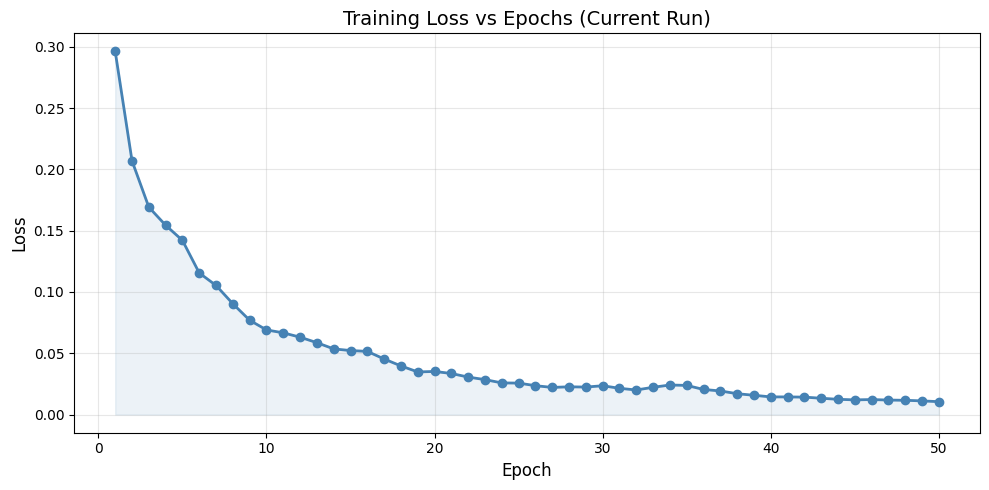

  Final loss : 0.0105
  Plot saved to: /Users/avishkashenan/Desktop/Line Segmentation New/data/logs/training_loss_curve.png


In [7]:
import matplotlib.pyplot as plt

# Uses losses from Step 4 if available, otherwise use the hardcoded reference values
if training_losses:
    loss_values = training_losses
    title = "Training Loss vs Epochs (Current Run)"
else:
    # Reference values from original training run
    loss_values = [
        0.3063, 0.1837, 0.1455, 0.1203, 0.1028,
        0.0929, 0.0840, 0.0723, 0.0623, 0.0541,
        0.0475, 0.0446, 0.0405, 0.0395, 0.0351
    ]
    title = "Training Loss vs Epochs (Reference Run)"

epochs = list(range(1, len(loss_values) + 1))

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss_values, marker='o', color='steelblue', linewidth=2, markersize=6)
plt.fill_between(epochs, loss_values, alpha=0.1, color='steelblue')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title(title, fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PATHS["logs"], "training_loss_curve.png"), dpi=150)
plt.show()

print(f"  Final loss : {loss_values[-1]:.4f}")
print(f"  Plot saved to: {PATHS['logs']}/training_loss_curve.png")

---
## 📌 STEP 6 — Run DeepLab Inference (Isolate Medicine Regions)
**What it does:** Loads your trained DeepLab model and runs it on all preprocessed images. Each pixel gets classified as 'medicine' or 'background'. The medicine region is kept, everything else goes black.

**Input:**  `data/preprocessed_images/` + `models/deeplab_medicine_detector.pth`  
**Output:** `data/isolated_medicines/`

In [8]:
import cv2
import torch
import torch.nn as nn
import numpy as np
import os
from torchvision import transforms
from torchvision.models.segmentation import deeplabv3_resnet50
from pathlib import Path
from tqdm import tqdm


def build_inference_model(model_path, device, num_classes=2):
    """Loads the saved DeepLab weights for inference."""
    model = deeplabv3_resnet50(weights=None, aux_loss=True)
    model.classifier[4]     = nn.Conv2d(256, num_classes, kernel_size=(1, 1))
    if model.aux_classifier is not None:
        model.aux_classifier[4] = nn.Conv2d(256, num_classes, kernel_size=(1, 1))
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model


def run_inference(input_dir, output_dir, model_path):
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    if not os.path.exists(model_path):
        print(f"❌ Model not found at {model_path}")
        print("   Please run Step 4 (training) first.")
        return

    # Hardware detection
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"  Running inference on: {device}")

    model = build_inference_model(model_path, device)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
    ])

    images = [f for f in os.listdir(input_dir)
               if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"  Processing {len(images)} images...")

    for img_name in tqdm(images):
        img_path     = os.path.join(input_dir, img_name)
        original_img = cv2.imread(img_path)
        if original_img is None:
            continue

        orig_h, orig_w = original_img.shape[:2]
        img_rgb    = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (512, 512))
        input_tensor = transform(img_resized).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)['out'][0]
            predicted_mask = output.argmax(0).byte().cpu().numpy()

        full_res_mask = cv2.resize(predicted_mask, (orig_w, orig_h),
                                    interpolation=cv2.INTER_NEAREST)
        isolated_img = cv2.bitwise_and(original_img, original_img,
                                        mask=full_res_mask)

        out_path = os.path.join(output_dir, img_name)
        cv2.imwrite(out_path, isolated_img)

    print(f"\n✅ Step 6 Complete!")
    print(f"   Isolated images saved to: {output_dir}")


# ── RUN STEP 6 ───────────────────────────────────────────────
run_inference(
    input_dir  = PATHS["preprocessed_images"],
    output_dir = PATHS["isolated_medicines"],
    model_path = os.path.join(PATHS["models"], "deeplab_medicine_detector.pth")
)

  Running inference on: mps
  Processing 600 images...


100%|██████████| 600/600 [01:03<00:00,  9.43it/s]


✅ Step 6 Complete!
   Isolated images saved to: /Users/avishkashenan/Desktop/Line Segmentation New/data/isolated_medicines


---
## 📌 STEP 7 — CRAFT Text Line Segmentation
**What it does:** Runs the CRAFT text detector on isolated medicine images to find individual handwritten lines. Merges over-fragmented detections, applies perspective correction, and saves each line as a standard 128×32 image.

**Prerequisites:**
1. Clone CRAFT: `git clone https://github.com/clovaai/CRAFT-pytorch.git libs/CRAFT-pytorch`
2. Download weights: `craft_mlt_25k.pth` → place in `models/`

**Input:**  `data/isolated_medicines/`  
**Output:** `data/segmented_lines/` — files named like `prescription_001_line_000.jpg`

In [9]:
import os
import sys
import cv2
import numpy as np
import torch
from pathlib import Path
from collections import OrderedDict
from torch.autograd import Variable


# ── CRAFT Compatibility Fix ───────────────────────────────────
import torchvision.models.vgg as vgg
if not hasattr(vgg, 'model_urls'):
    vgg.model_urls = {'vgg16_bn': 'https://download.pytorch.org/models/vgg16_bn-6c64b313.pth'}

# ── Add CRAFT to Python path ──────────────────────────────────
craft_repo_dir = os.path.join(PROJECT_ROOT, "libs", "CRAFT-pytorch")
if craft_repo_dir not in sys.path:
    sys.path.append(craft_repo_dir)

try:
    from craft import CRAFT
    import craft_utils
    import imgproc
    print("  ✅ CRAFT imported successfully")
except ImportError as e:
    print(f"\n❌ ERROR: Could not import CRAFT.")
    print(f"   Path searched: {craft_repo_dir}")
    print(f"   Error: {e}")
    print("\n   Please run this first:")
    print(f"   git clone https://github.com/clovaai/CRAFT-pytorch.git {craft_repo_dir}")
    raise


# ── CRAFT Helper Functions ────────────────────────────────────
def copyStateDict(state_dict):
    start_idx = 1 if list(state_dict.keys())[0].startswith("module") else 0
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        name = ".".join(k.split(".")[start_idx:])
        new_state_dict[name] = v
    return new_state_dict


def load_craft_model(model_path):
    if not os.path.exists(model_path):
        print(f"❌ CRAFT weights not found at {model_path}")
        print("   Download craft_mlt_25k.pth and place it in models/")
        return None, None

    net = CRAFT()
    if torch.backends.mps.is_available():
        device = "mps"
    elif torch.cuda.is_available():
        device = "cuda"
    else:
        device = "cpu"

    print(f"  Loading CRAFT on: {device}")
    weights = torch.load(model_path, map_location='cpu')
    net.load_state_dict(copyStateDict(weights))
    net = net.to(device)
    net.eval()
    return net, device


def get_text_polygons(net, image, params, device):
    img_resized, target_ratio, _ = imgproc.resize_aspect_ratio(
        image, params['canvas_size'],
        interpolation=cv2.INTER_LINEAR,
        mag_ratio=params['mag_ratio']
    )
    ratio_h = ratio_w = 1 / target_ratio
    x = imgproc.normalizeMeanVariance(img_resized)
    x = torch.from_numpy(x).permute(2, 0, 1)
    x = Variable(x.unsqueeze(0)).to(device)
    with torch.no_grad():
        y, _ = net(x)
    score_text = y[0, :, :, 0].cpu().data.numpy()
    score_link = y[0, :, :, 1].cpu().data.numpy()
    boxes, polys = craft_utils.getDetBoxes(
        score_text, score_link,
        params['text_threshold'], params['link_threshold'],
        params['low_text'], params['poly']
    )
    boxes  = craft_utils.adjustResultCoordinates(boxes, ratio_w, ratio_h)
    polys  = craft_utils.adjustResultCoordinates(polys, ratio_w, ratio_h)
    for k in range(len(polys)):
        if polys[k] is None:
            polys[k] = boxes[k]
    return polys


def merge_craft_polygons(polys, merge_threshold=45):
    if len(polys) == 0:
        return []
    rects = []
    for poly in polys:
        pts = np.array(poly, dtype=np.float32)
        x, y, w, h = cv2.boundingRect(pts)
        rects.append([x, y, w, h])
    rects.sort(key=lambda b: b[1])

    lines = []
    current_line = [rects[0]]
    for rect in rects[1:]:
        prev = current_line[-1]
        if abs(rect[1] - prev[1]) < (prev[3] * 0.5):
            current_line.append(rect)
        else:
            lines.append(current_line)
            current_line = [rect]
    lines.append(current_line)

    merged_rects = []
    for line in lines:
        line.sort(key=lambda b: b[0])
        merged_box = line[0]
        for next_box in line[1:]:
            x1, y1, w1, h1 = merged_box
            x2, y2, w2, h2 = next_box
            gap = x2 - (x1 + w1)
            if gap < merge_threshold:
                merged_box = [x1, min(y1, y2), (x2 + w2) - x1,
                              max(y1 + h1, y2 + h2) - min(y1, y2)]
            else:
                merged_rects.append(merged_box)
                merged_box = next_box
        merged_rects.append(merged_box)

    return [
        [[x, y], [x+w, y], [x+w, y+h], [x, y+h]]
        for (x, y, w, h) in merged_rects
    ]


def crop_and_warp(img, poly):
    pts = np.array(poly, dtype=np.float32)
    max_width  = int(max(np.linalg.norm(pts[0]-pts[1]), np.linalg.norm(pts[3]-pts[2])))
    max_height = int(max(np.linalg.norm(pts[0]-pts[3]), np.linalg.norm(pts[1]-pts[2])))
    if max_width == 0 or max_height == 0:
        return None
    dst_pts = np.array([[0, 0], [max_width-1, 0],
                         [max_width-1, max_height-1], [0, max_height-1]], dtype="float32")
    M = cv2.getPerspectiveTransform(pts, dst_pts)
    return cv2.warpPerspective(img, M, (max_width, max_height))


def resize_and_pad(img, target_w=128, target_h=32):
    if img is None or img.size == 0:
        return None
    h, w = img.shape[:2]
    if h == 0 or w == 0:
        return None
    scale  = min(target_w / w, target_h / h)
    new_w  = max(1, int(w * scale))
    new_h  = max(1, int(h * scale))
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    padded  = (np.ones((target_h, target_w, 3), dtype=np.uint8) * 255
               if len(img.shape) == 3
               else np.ones((target_h, target_w), dtype=np.uint8) * 255)
    y_off = (target_h - new_h) // 2
    if len(img.shape) == 3:
        padded[y_off:y_off+new_h, 0:new_w, :] = resized
    else:
        padded[y_off:y_off+new_h, 0:new_w] = resized
    return padded


def run_craft_segmentation(input_dir, output_dir, model_path, merge_threshold=45):
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    params = {
        'text_threshold': 0.7,
        'link_threshold': 0.4,
        'low_text':       0.4,
        'cuda':           True,
        'poly':           False,
        'canvas_size':    1280,
        'mag_ratio':      1.5
    }

    net, device = load_craft_model(model_path)
    if net is None:
        return

    image_paths = sorted([
        os.path.join(input_dir, f)
        for f in os.listdir(input_dir)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    if not image_paths:
        print(f"⚠️  No images in {input_dir}")
        return

    total_crops = 0
    print(f"  Running CRAFT on {len(image_paths)} images...")

    for img_path in image_paths:
        img_name  = os.path.basename(img_path)
        image     = cv2.imread(img_path)
        if image is None:
            continue
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        raw_polys = get_text_polygons(net, image_rgb, params, device)
        polys     = merge_craft_polygons(raw_polys, merge_threshold)
        if polys:
            polys = sorted(polys, key=lambda p: (p[0][1], p[0][0]))

        crops_saved = 0
        for i, poly in enumerate(polys):
            cropped    = crop_and_warp(image, poly)
            final_crop = resize_and_pad(cropped)
            if final_crop is None:
                continue
            base_name   = os.path.splitext(img_name)[0]
            out_filename = f"{base_name}_line_{i:03d}.jpg"
            cv2.imwrite(os.path.join(output_dir, out_filename), final_crop)
            crops_saved += 1
            total_crops += 1

        print(f"    {img_name} → {crops_saved} lines")

    print(f"\n✅ Step 7 Complete!")
    print(f"   {total_crops} line crops saved to: {output_dir}")
    print(f"   Format: 128×32 JPG  |  Named: <prescription>_line_NNN.jpg")


# ── RUN STEP 7 ───────────────────────────────────────────────
# merge_threshold: increase if lines are split too much, decrease if lines are merging together
run_craft_segmentation(
    input_dir       = PATHS["isolated_medicines"],
    output_dir      = PATHS["segmented_lines"],
    model_path      = os.path.join(PATHS["models"], "craft_mlt_25k.pth"),
    merge_threshold = 45
)

  ✅ CRAFT imported successfully


/Users/avishkashenan/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/avishkashenan/miniconda3/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


  Loading CRAFT on: mps
  Running CRAFT on 600 images...
    176805_1.jpg → 3 lines
    176808_0.jpg → 2 lines
    176809_0.jpg → 5 lines
    176813_0.jpg → 5 lines
    176817_0.jpg → 7 lines
    176820_0.jpg → 2 lines
    176821_0.jpg → 16 lines
    176823_0.jpg → 1 lines
    176828_0.jpg → 8 lines
    176828_1.jpg → 7 lines
    176830_0.jpg → 6 lines
    176833_0.jpg → 6 lines
    176833_1.jpg → 4 lines
    176840_0.jpg → 8 lines
    176840_1.jpg → 9 lines
    176842_0.jpg → 0 lines
    176845_0.jpg → 6 lines
    176846_0.jpg → 4 lines
    176847_0.jpg → 3 lines
    176848_0.jpg → 2 lines
    176851_0.jpg → 4 lines
    176854_0.jpg → 2 lines
    176856_0.jpg → 1 lines
    176857_0.jpg → 10 lines
    176858_0.jpg → 7 lines
    176860_0.jpg → 0 lines
    176862_0.jpg → 11 lines
    176863_0.jpg → 1 lines
    176866_1.jpg → 2 lines
    176867_0.jpg → 5 lines
    176868_0.jpg → 1 lines
    176873_0.jpg → 8 lines
    176873_1.jpg → 9 lines
    176874_0.jpg → 9 lines
    176875_0.jpg → 4 l

---
## 📌 STEP 8 — Save Everything for HTR Model (Handoff)
**What it does:** Creates a clean `htr_input/` folder with everything the HTR model needs:
- All 128×32 line crop images
- The trained DeepLab model weights
- A `pipeline_config.json` file with all paths, settings, and dataset stats

**This is your handoff package to the next workflow.**

In [10]:
import shutil
import json
from datetime import datetime


def save_htr_handoff(paths, project_root):
    print("Preparing HTR handoff package...\n")

    # 1. Copy all line crops to htr_input/line_crops/
    line_crops_src = paths["segmented_lines"]
    line_crops_dst = paths["htr_line_crops"]
    Path(line_crops_dst).mkdir(parents=True, exist_ok=True)

    crop_files = [f for f in os.listdir(line_crops_src)
                  if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

    print(f"  Copying {len(crop_files)} line crops...")
    for f in crop_files:
        shutil.copy2(os.path.join(line_crops_src, f),
                     os.path.join(line_crops_dst, f))

    # 2. Copy trained DeepLab model
    deeplab_src  = os.path.join(paths["models"], "deeplab_medicine_detector.pth")
    deeplab_dst  = os.path.join(paths["htr_input"], "deeplab_medicine_detector.pth")
    if os.path.exists(deeplab_src):
        shutil.copy2(deeplab_src, deeplab_dst)
        print(f"  ✅ DeepLab model copied")
    else:
        print(f"  ⚠️  DeepLab model not found — run Step 4 first")

    # 3. Save pipeline config JSON
    config = {
        "pipeline": "Prescription Line Segmentation",
        "created_at": datetime.now().isoformat(),
        "next_stage": "HTR (Handwritten Text Recognition)",

        "input_format": {
            "description": "128x32 grayscale JPG images of individual handwritten medicine lines",
            "width":  128,
            "height": 32,
            "format": "JPG",
            "naming_convention": "<prescription_name>_line_NNN.jpg"
        },

        "dataset_stats": {
            "total_line_crops":       len(crop_files),
            "raw_images":             len(os.listdir(paths['raw_images'])) if os.path.exists(paths['raw_images']) else 0,
            "annotated_masks":        len([f for f in os.listdir(paths['segmentation_masks'])
                                           if f.lower().endswith(('.png','.jpg','.jpeg'))])
                                      if os.path.exists(paths['segmentation_masks']) else 0,
        },

        "models": {
            "deeplab": {
                "file":          "deeplab_medicine_detector.pth",
                "architecture":  "DeepLabV3+ ResNet50",
                "num_classes":   2,
                "classes":       {"0": "background", "1": "medicine_region"},
                "input_size":    [512, 512],
                "trained_epochs": 15
            },
            "craft": {
                "file":         "craft_mlt_25k.pth (external — not copied)",
                "purpose":      "Text line detection and segmentation",
                "source":       "https://github.com/clovaai/CRAFT-pytorch"
            }
        },

        "pipeline_steps": [
            "1. Deskew + preprocess (grayscale, adaptive threshold, dilation)",
            "2. ROI extraction (remove header/footer)",
            "3. Manual polygon annotation",
            "4. Train DeepLabV3+ segmentation model",
            "5. Run inference to isolate medicine regions",
            "6. CRAFT text detection + line crop extraction",
            "7. Perspective correction + 128x32 resize/pad"
        ],

        "paths": {
            "line_crops_folder":  line_crops_dst,
            "deeplab_model":      deeplab_dst,
            "project_root":       project_root
        },

        "htr_recommendation": {
            "suggested_models": ["CRNN", "TrOCR", "SVTR", "PaddleOCR"],
            "note": "Feed line_crops/ images as inputs. Each image is one medicine line."
        }
    }

    config_path = os.path.join(paths["htr_input"], "pipeline_config.json")
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)

    print(f"\n{'='*55}")
    print(f"✅  HTR HANDOFF PACKAGE READY")
    print(f"{'='*55}")
    print(f"  📁 Location       : {paths['htr_input']}")
    print(f"  🖼️  Line crops     : {len(crop_files)} images (128×32 JPG)")
    print(f"  🧠 DeepLab model  : deeplab_medicine_detector.pth")
    print(f"  📋 Config file    : pipeline_config.json")
    print(f"{'='*55}")
    print(f"\n  👉 Pass htr_input/line_crops/ to your HTR model as input.")
    print(f"  👉 Load pipeline_config.json in your HTR code for metadata.")


# ── RUN STEP 8 ───────────────────────────────────────────────
save_htr_handoff(PATHS, PROJECT_ROOT)

Preparing HTR handoff package...

  Copying 3774 line crops...
  ✅ DeepLab model copied

✅  HTR HANDOFF PACKAGE READY
  📁 Location       : /Users/avishkashenan/Desktop/Line Segmentation New/htr_input
  🖼️  Line crops     : 3774 images (128×32 JPG)
  🧠 DeepLab model  : deeplab_medicine_detector.pth
  📋 Config file    : pipeline_config.json

  👉 Pass htr_input/line_crops/ to your HTR model as input.
  👉 Load pipeline_config.json in your HTR code for metadata.


---
## 🔍 Quick Sanity Check — View Sample Line Crops
Run this to visually confirm the final outputs look correct before passing to HTR.

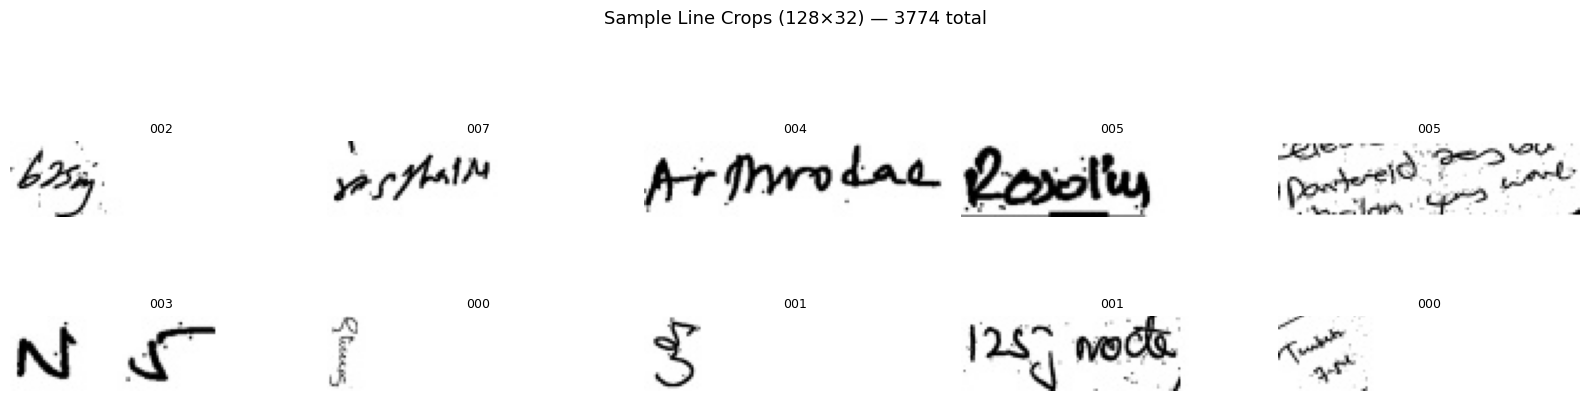

Total line crops ready for HTR: 3774


In [11]:
import matplotlib.pyplot as plt
import cv2
import os
import random

line_crop_dir = PATHS["htr_line_crops"]
all_crops = [f for f in os.listdir(line_crop_dir) if f.endswith('.jpg')]

if not all_crops:
    print("No line crops found. Run Steps 6 and 7 first.")
else:
    sample = random.sample(all_crops, min(10, len(all_crops)))
    fig, axes = plt.subplots(2, 5, figsize=(16, 5))
    axes = axes.flatten()

    for i, fname in enumerate(sample):
        img = cv2.imread(os.path.join(line_crop_dir, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(fname.split('_line_')[1].replace('.jpg',''), fontsize=9)
        axes[i].axis('off')

    plt.suptitle(f"Sample Line Crops (128×32) — {len(all_crops)} total", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(PATHS["logs"], "sample_line_crops.png"), dpi=150)
    plt.show()
    print(f"Total line crops ready for HTR: {len(all_crops)}")